In [112]:
import torch
import torch.nn as nn
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from model import LSTMClassifier
import pandas as pd

In [113]:
# from dataWorker import getOHLC

# # load all btc candles from 1'st Jan 2026

# iters = 300

# df = pd.DataFrame()
# for i in range(iters):
#     df_1000mins = getOHLC('BTCUSDT', (1767214800+60*i*1000)*1000, (1767214800+60*(i+1)*1000-60)*1000, normalize=False)
#     df = pd.concat([df, df_1000mins], axis=0)
#     print(f"{i+1}/{iters}", len(df))

# # save to parquet
# df.to_parquet('data/real/btcusdt_7months.parquet')

In [114]:
def predict(model, df, feature_cols, window=60, device="cuda"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [115]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=len(feature_cols), hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_1440_450_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [116]:
import random
intervals = []

for i in range(100):
    random_hour = random.randint(0,10000)
    start = ( 1784365200-60*60*random_hour-60*90 )*1000
    end = ( 1784365200-60*60*random_hour )*1000
    intervals.append([start, end])
 
print(intervals)  
intervals = [[1767443400000, 1767448800000], [1766665800000, 1766671200000], [1764365400000, 1764370800000], [1748554200000, 1748559600000], [1777069800000, 1777075200000], [1764484200000, 1764489600000], [1765765800000, 1765771200000], [1770834600000, 1770840000000], [1763649000000, 1763654400000], [1749357000000, 1749362400000], [1754073000000, 1754078400000], [1780180200000, 1780185600000], [1773451800000, 1773457200000], [1754526600000, 1754532000000], [1781191800000, 1781197200000], [1754530200000, 1754535600000], [1758047400000, 1758052800000], [1773358200000, 1773363600000], [1780158600000, 1780164000000], [1773876600000, 1773882000000], [1769092200000, 1769097600000], [1775169000000, 1775174400000], [1783985400000, 1783990800000], [1752571800000, 1752577200000], [1754879400000, 1754884800000], [1751002200000, 1751007600000], [1750419000000, 1750424400000], [1773088200000, 1773093600000], [1776983400000, 1776988800000], [1751916600000, 1751922000000], [1755999000000, 1756004400000], [1778034600000, 1778040000000], [1757320200000, 1757325600000], [1771597800000, 1771603200000], [1775615400000, 1775620800000], [1778704200000, 1778709600000], [1782102600000, 1782108000000], [1756153800000, 1756159200000], [1749594600000, 1749600000000], [1777998600000, 1778004000000], [1764732600000, 1764738000000], [1758015000000, 1758020400000], [1766133000000, 1766138400000], [1766356200000, 1766361600000], [1781476200000, 1781481600000], [1781595000000, 1781600400000], [1764084600000, 1764090000000], [1767331800000, 1767337200000], [1757802600000, 1757808000000], [1764444600000, 1764450000000], [1748388600000, 1748394000000], [1774125000000, 1774130400000], [1755934200000, 1755939600000], [1765103400000, 1765108800000], [1759368600000, 1759374000000], [1749231000000, 1749236400000], [1754159400000, 1754164800000], [1763670600000, 1763676000000], [1752341400000, 1752346800000], [1765499400000, 1765504800000], [1763386200000, 1763391600000], [1760178600000, 1760184000000], [1759091400000, 1759096800000], [1781580600000, 1781586000000], [1770298200000, 1770303600000], [1783783800000, 1783789200000], [1754731800000, 1754737200000], [1783636200000, 1783641600000], [1771270200000, 1771275600000], [1748964600000, 1748970000000], [1769157000000, 1769162400000], [1780612200000, 1780617600000], [1760941800000, 1760947200000], [1761982200000, 1761987600000], [1773012600000, 1773018000000], [1757953800000, 1757959200000], [1748773800000, 1748779200000], [1750278600000, 1750284000000], [1749540600000, 1749546000000], [1776493800000, 1776499200000], [1765909800000, 1765915200000], [1765935000000, 1765940400000], [1782307800000, 1782313200000], [1775475000000, 1775480400000], [1777757400000, 1777762800000], [1762943400000, 1762948800000], [1765513800000, 1765519200000], [1769542200000, 1769547600000], [1757143800000, 1757149200000], [1763224200000, 1763229600000], [1777350600000, 1777356000000], [1781573400000, 1781578800000], [1776263400000, 1776268800000], [1756884600000, 1756890000000], [1768523400000, 1768528800000], [1750055400000, 1750060800000], [1781512200000, 1781517600000], [1757849400000, 1757854800000], [1780817400000, 1780822800000], [1760275800000, 1760281200000]]

[[1755027000000, 1755032400000], [1751502600000, 1751508000000], [1771774200000, 1771779600000], [1766377800000, 1766383200000], [1767753000000, 1767758400000], [1765567800000, 1765573200000], [1771018200000, 1771023600000], [1754148600000, 1754154000000], [1750689000000, 1750694400000], [1776598200000, 1776603600000], [1782664200000, 1782669600000], [1777203000000, 1777208400000], [1770683400000, 1770688800000], [1753943400000, 1753948800000], [1749025800000, 1749031200000], [1769391000000, 1769396400000], [1782261000000, 1782266400000], [1754134200000, 1754139600000], [1756942200000, 1756947600000], [1775849400000, 1775854800000], [1767972600000, 1767978000000], [1761294600000, 1761300000000], [1776115800000, 1776121200000], [1776216600000, 1776222000000], [1780666200000, 1780671600000], [1760088600000, 1760094000000], [1749310200000, 1749315600000], [1771803000000, 1771808400000], [1760401800000, 1760407200000], [1760898600000, 1760904000000], [1773102600000, 1773108000000], [176333

288854
1.0    288853
Name: count, dtype: int64


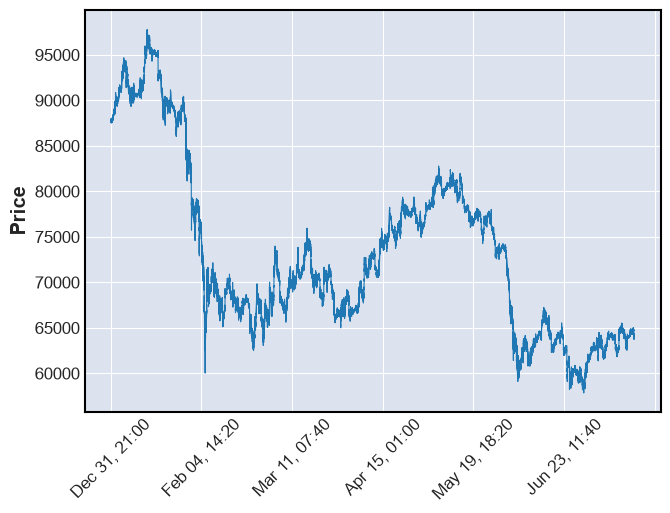

Loaded 2310 windows


In [117]:
# load from parquest
df = pd.read_parquet('data/real/btcusdt_bear_7months.parquet')

import mplfinance as mpl

df = df.drop(columns=['volume', 'quote_volume'])

# check for gaps in chart
df = df.sort_values('timestamp').reset_index(drop=True)
print(len(df))
print(df.index.to_series().diff().value_counts())

#  plotting for debug
df_plot = df.set_index("timestamp")
mpl.plot(df_plot, type="line")


window_size = 125
input_size = 120

inputs_windows, result_windows = [], []
for i in range(0, len(df)-window_size+1, window_size):
    window = df.iloc[i:i+window_size]

    inputs_windows.append(window.iloc[:input_size])
    result_windows.append(window.iloc[input_size:])
    
print(f"Loaded {len(inputs_windows)} windows")

In [ ]:
from dataWorker import *
from datetime import datetime
from dataWorker import getOHLC, normalizeDataFrame
import matplotlib.pyplot as plt
# loading real data for test

profit_ttl = 0
wins = 0
risk = 17
rr = 2.25

profit_history = []
winrate_history = []
iters = len(inputs_windows)
for i, df in enumerate(inputs_windows):

    #print(len(df))
    df_input = normalizeDataFrame(df)
    df_input = prepare_features_and_labels(df_input, horizon=5, flat_threshold=0.001) 
    result = predict(model, df_input, feature_cols, window=60)

    
    # collecting data from exchange
    df_plot = df.set_index("timestamp")
    df_result = result_windows[i]
    #df_result = df_final.set_index("timestamp")

    open_price = float(df_result.iloc[0]['open'])
    # check for stop-loss or take-profit
    
    take_profit = risk*rr
    stop_loss = risk
    
    for j in range(5):
        if result.get('prediction') == 'up' : 
            if df_result.iloc[j]['high'] >= open_price + take_profit:
                profit = take_profit
                break
            if df_result.iloc[j]['low'] <= open_price - stop_loss:
                profit = stop_loss*-1
                break
        if result.get('prediction') == 'down' : 
            if df_result.iloc[j]['high'] >= open_price + stop_loss:
                profit = stop_loss*-1
                break
            if df_result.iloc[j]['low'] <= open_price - take_profit:
                profit = take_profit
                break
        else:
            profit = round(df_result.iloc[j]['close']  - open_price, 3)
    
    
    if profit>0: wins += 1
    profit_ttl += profit
    profit_ttl = round(profit_ttl, 2)
    print(f"{i+1}/{iters} {'win' if profit>0 else 'loss'}, prediction {result.get('prediction')} {round(result.get('probabilities').get(result.get('prediction'))*100,5)}, profit {profit} points, ttl {profit_ttl}, winrate {round(wins/(i+1),4)}")
    
    profit_history.append(profit_ttl)
    if i>=10:
        winrate_history.append(round(wins/(i+1),3))
    
    
print(f"Profit: {profit_ttl} points with winrate {round(wins/iters,4)}. risk {risk} and R/R {rr}")    

fig, ax = plt.subplots()
t = np.arange(1,iters+1, 1)
ax.plot(t, profit_history, lw=0.8)
ax.set(xlabel='i', ylabel='profit',
       title='Profit graph'
)
ax.grid(visible=True, axis='both')
plt.show()

fig, ax = plt.subplots()
ax.plot(t[10:], winrate_history, lw=0.8)
ax.set(xlabel='i', ylabel='winrate',
       title='Winrate graph'
)
ax.grid(visible=True, axis='both')
plt.show()

1/2310 win, prediction down 99.0044, profit 38.25 points, ttl 38.25, winrate 1.0
2/2310 loss, prediction down 99.20385, profit -17 points, ttl 21.25, winrate 0.5
3/2310 win, prediction up 99.99768, profit 38.25 points, ttl 59.5, winrate 0.667
4/2310 loss, prediction down 94.40259, profit -17 points, ttl 42.5, winrate 0.5
5/2310 loss, prediction down 100.0, profit -17 points, ttl 25.5, winrate 0.4
6/2310 loss, prediction up 99.99712, profit -17 points, ttl 8.5, winrate 0.333
7/2310 loss, prediction down 99.99996, profit -17 points, ttl -8.5, winrate 0.286
8/2310 loss, prediction down 99.71958, profit -17 points, ttl -25.5, winrate 0.25
9/2310 win, prediction up 99.89518, profit 38.25 points, ttl 12.75, winrate 0.333
10/2310 loss, prediction down 50.83666, profit -17 points, ttl -4.25, winrate 0.3
11/2310 loss, prediction down 100.0, profit -17 points, ttl -21.25, winrate 0.273
12/2310 loss, prediction down 100.0, profit -17 points, ttl -38.25, winrate 0.25
13/2310 loss, prediction down 

In [ ]:
# from dataWorker import getOHLC
# import mplfinance as mpf

# df_plot = getOHLC('BTCUSDT', start, end)
# df_plot = df_plot.set_index("timestamp")
# df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
# df_final = df_final.set_index("timestamp")

# open_price = float(df_final.iloc[0]['open'])
# close_price = float(df_final.iloc[4]['close'])

# profit = round(close_price - open_price, 3)
# if result.get('prediction') == 'down':
#     if profit < 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')
# if result.get('prediction') == 'up':
#     if profit > 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')

# # plotting
# fig, ax = mpf.plot(df_plot, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Input Data')
# fig,ax = mpf.plot(df_final, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Prediction Window')